In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 11
fig_height = 5.5
fig_format = 'png'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'RDpcUmVwb3NpdG9yaWVzXEFENjk4LWdlbmVyYXRpdmUtYWktZm9yLUJBXE0z'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Program Files\\Python312\\Lib\\importlib\\_bootstrap.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\zipimport.py": 1744131414.0, "C:\\Program Files\\Python312\\Lib\\codecs.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\aliases.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\__init__.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\utf_8.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\cp1252.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\abc.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\io.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\stat.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\_collections_abc.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\genericpath.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\ntpath.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\o

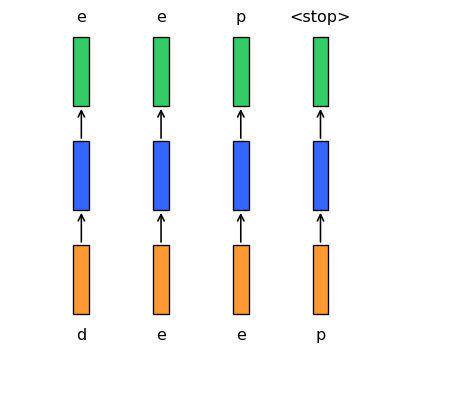

In [2]:
#| echo: false
#| eval: true
#| fig-align: center
#| fig-alt: Diagram showing a sequence of inputs and outputs for an auto-completion task.
#| fig-cap: Diagram showing a sequence of inputs and outputs for an auto-completion task.
#| label: fig-autocomplete-sequence

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np

COLOR_IN   = np.array([1.0, 0.6, 0.2])   # orange
COLOR_CELL = np.array([0.2, 0.4, 1.0])   # blue
COLOR_OUT  = np.array([0.2, 0.8, 0.4])   # green

def draw_box(ax, x, y, w, h, color, text, valign="center", pad=0.30):
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor='black')
    ax.add_patch(rect)

    cx = x + w/2

    if valign == "center":
        cy = y + h/2
    elif valign == "top":
        cy = y + h - pad*h
    elif valign == "bottom":
        cy = y + pad*h
    elif valign == "above":
        cy = y + h + pad*h
    elif valign == "below":
        cy = y - pad*h
    else:
        cy = y + h/2

    ax.text(cx, cy, text, ha='center', va='center', fontsize=12)
    return rect

def arrow_down(ax, top_rect, bottom_rect):
    x_mid = top_rect.get_x() + top_rect.get_width()/2
    y_start = top_rect.get_y()
    y_end = bottom_rect.get_y() + bottom_rect.get_height()

    arrow = FancyArrowPatch(
        (x_mid, y_start),
        (x_mid, y_end),
        arrowstyle='<-',
        mutation_scale=12,
        color='black',
        linewidth=1.2
    )
    ax.add_patch(arrow)

def draw_vertical_column(ax, x, inp, out):
    w, h = 0.25, 1.50
    gap = 0.75

    top_y = 0
    top_box = draw_box(ax, x, top_y, w, h, COLOR_OUT, out, valign="above")

    mid_y = top_y - h - gap
    mid_box = draw_box(ax, x, mid_y, w, h, COLOR_CELL, "", valign="center")

    bot_y = mid_y - h - gap
    bot_box = draw_box(ax, x, bot_y, w, h, COLOR_IN, inp, valign="below")

    arrow_down(ax, top_box, mid_box)
    arrow_down(ax, mid_box, bot_box)

def draw_sequence_vertical(inputs, outputs, column_spacing=2.0,
                           save_svg=False, svg_path="diagram.svg"):
    fig, ax = plt.subplots(figsize=(len(inputs)*1.5, 5))

    for i, (inp, out) in enumerate(zip(inputs, outputs)):
        draw_vertical_column(ax, x=i*column_spacing, inp=inp, out=out)

    ax.set_xlim(-1, len(inputs)*column_spacing + 1)
    ax.set_ylim(-6, 2)
    ax.axis('off')

    if save_svg:
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        # print(f"Saved SVG to {svg_path}")

    plt.show()

# Example usage
inputs = ["d", "e", "e", "p"]
outputs = ["e", "e", "p", "<stop>"]
column_spacing = 1.25
output_loc = "./M03_lecture02_figures/rnn_sequence.svg"
draw_sequence_vertical(inputs, outputs, column_spacing=column_spacing, save_svg=True, svg_path=output_loc)

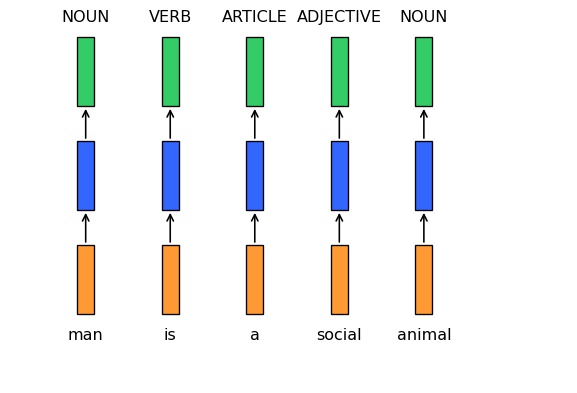

In [3]:
#| echo: false
#| eval: true
#| fig-align: center
#| fig-alt: Diagram showing a sequence of inputs and outputs for a part-of-speech tagging task.
#| fig-cap: Diagram showing a sequence of inputs and outputs for a part-of-speech tagging task.
#| label: fig-pos-tagging-sequence

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np

COLOR_IN   = np.array([1.0, 0.6, 0.2])   # orange
COLOR_CELL = np.array([0.2, 0.4, 1.0])   # blue
COLOR_OUT  = np.array([0.2, 0.8, 0.4])   # green

def draw_box(ax, x, y, w, h, color, text, valign="center", pad=0.30):
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor='black')
    ax.add_patch(rect)

    cx = x + w/2

    if valign == "center":
        cy = y + h/2
    elif valign == "top":
        cy = y + h - pad*h
    elif valign == "bottom":
        cy = y + pad*h
    elif valign == "above":
        cy = y + h + pad*h
    elif valign == "below":
        cy = y - pad*h
    else:
        cy = y + h/2

    ax.text(cx, cy, text, ha='center', va='center', fontsize=12)
    return rect

def arrow_down(ax, top_rect, bottom_rect):
    x_mid = top_rect.get_x() + top_rect.get_width()/2
    y_start = top_rect.get_y()
    y_end = bottom_rect.get_y() + bottom_rect.get_height()

    arrow = FancyArrowPatch(
        (x_mid, y_start),
        (x_mid, y_end),
        arrowstyle='<-',
        mutation_scale=12,
        color='black',
        linewidth=1.2
    )
    ax.add_patch(arrow)

def draw_vertical_column(ax, x, inp, out):
    w, h = 0.25, 1.50
    gap = 0.75

    top_y = 0
    top_box = draw_box(ax, x, top_y, w, h, COLOR_OUT, out, valign="above")

    mid_y = top_y - h - gap
    mid_box = draw_box(ax, x, mid_y, w, h, COLOR_CELL, "", valign="center")

    bot_y = mid_y - h - gap
    bot_box = draw_box(ax, x, bot_y, w, h, COLOR_IN, inp, valign="below")

    arrow_down(ax, top_box, mid_box)
    arrow_down(ax, mid_box, bot_box)

def draw_sequence_vertical(inputs, outputs, column_spacing=2.0,
                           save_svg=False, svg_path="diagram.svg"):
    fig, ax = plt.subplots(figsize=(len(inputs)*1.5, 5))

    for i, (inp, out) in enumerate(zip(inputs, outputs)):
        draw_vertical_column(ax, x=i*column_spacing, inp=inp, out=out)

    ax.set_xlim(-1, len(inputs)*column_spacing + 1)
    ax.set_ylim(-6, 2)
    ax.axis('off')

    if save_svg:
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        # print(f"Saved SVG to {svg_path}")

    plt.show()

# Example usage
inputs = ["man", "is", "a", "social", "animal"]
outputs = ["NOUN", "VERB", "ARTICLE", "ADJECTIVE", "NOUN"]
column_spacing = 1.25
output_loc = "./M03_lecture02_figures/rnn_pos_tagging.svg"
draw_sequence_vertical(inputs, outputs, column_spacing=column_spacing, save_svg=True, svg_path=output_loc)

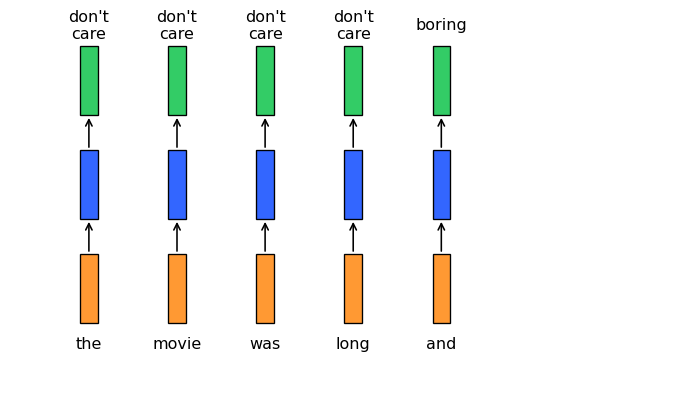

In [4]:
#| echo: false
#| eval: true
#| fig-align: center
#| fig-alt: Diagram showing a sentiment as a sequence to label problem
#| fig-cap: Diagram showing a sentiment as a sequence to label problem
#| label: fig-sentiment-sequence

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np

COLOR_IN   = np.array([1.0, 0.6, 0.2])   # orange
COLOR_CELL = np.array([0.2, 0.4, 1.0])   # blue
COLOR_OUT  = np.array([0.2, 0.8, 0.4])   # green

def draw_box(ax, x, y, w, h, color, text, valign="center", pad=0.30):
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor='black')
    ax.add_patch(rect)

    cx = x + w/2

    if valign == "center":
        cy = y + h/2
    elif valign == "top":
        cy = y + h - pad*h
    elif valign == "bottom":
        cy = y + pad*h
    elif valign == "above":
        cy = y + h + pad*h
    elif valign == "below":
        cy = y - pad*h
    else:
        cy = y + h/2

    ax.text(cx, cy, text, ha='center', va='center', fontsize=12)
    return rect

def arrow_down(ax, top_rect, bottom_rect):
    x_mid = top_rect.get_x() + top_rect.get_width()/2
    y_start = top_rect.get_y()
    y_end = bottom_rect.get_y() + bottom_rect.get_height()

    arrow = FancyArrowPatch(
        (x_mid, y_start),
        (x_mid, y_end),
        arrowstyle='<-',
        mutation_scale=12,
        color='black',
        linewidth=1.2
    )
    ax.add_patch(arrow)

def draw_vertical_column(ax, x, inp, out):
    w, h = 0.25, 1.50
    gap = 0.75

    top_y = 0
    top_box = draw_box(ax, x, top_y, w, h, COLOR_OUT, out, valign="above")

    mid_y = top_y - h - gap
    mid_box = draw_box(ax, x, mid_y, w, h, COLOR_CELL, "", valign="center")

    bot_y = mid_y - h - gap
    bot_box = draw_box(ax, x, bot_y, w, h, COLOR_IN, inp, valign="below")

    arrow_down(ax, top_box, mid_box)
    arrow_down(ax, mid_box, bot_box)

def draw_sequence_vertical(inputs, outputs, column_spacing=2.0,
                           save_svg=False, svg_path="diagram.svg"):
    fig, ax = plt.subplots(figsize=(len(inputs)*1.5, 5))

    for i, (inp, out) in enumerate(zip(inputs, outputs)):
        draw_vertical_column(ax, x=i*column_spacing, inp=inp, out=out)

    ax.set_xlim(-1, len(inputs)*column_spacing + 1)
    ax.set_ylim(-6, 2)
    ax.axis('off')

    if save_svg:
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        # print(f"Saved SVG to {svg_path}")

    plt.show()

# Example usage
inputs = ["the", "movie", "was", "long", "and", ""]
outputs = ["don't\ncare", "don't\ncare", "don't\ncare", "don't\ncare", "boring"]
column_spacing = 1.25
output_loc = "./M03_lecture02_figures/rnn_sequence-to-label.svg"
draw_sequence_vertical(inputs, outputs, column_spacing=column_spacing, save_svg=True, svg_path=output_loc)

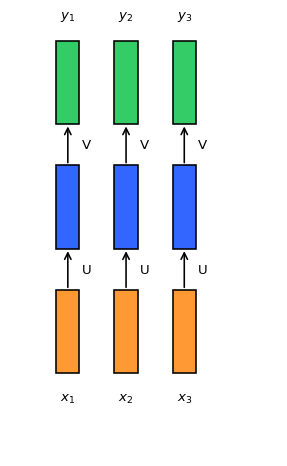

In [5]:
#| echo: false
#| eval: true
#| fig-align: center
#| fig-alt: "Diagram showing a sequence of inputs and outputs for an auto-completion task."
#| fig-cap: "Diagram showing a sequence of inputs and outputs for an auto-completion task."

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import numpy as np

# ---------------------------------------------------------
# COLORS
# ---------------------------------------------------------
COLOR_IN   = np.array([1.0, 0.6, 0.2])   # orange
COLOR_CELL = np.array([0.2, 0.4, 1.0])   # blue
COLOR_OUT  = np.array([0.2, 0.8, 0.4])   # green


# ---------------------------------------------------------
# BOX DRAWING (with inside labels + side labels + edge styles)
# ---------------------------------------------------------
def draw_box(ax, x, y, w, h, color, text,
             valign="center", pad=0.30,
             side_label=None, side="left", side_pad=0.25,
             edge_style="solid"):

    rect = Rectangle(
        (x, y), w, h,
        facecolor=color,
        edgecolor='black',
        linestyle=edge_style,
        linewidth=1.2
    )
    ax.add_patch(rect)

    # Inside label vertical placement
    cx = x + w/2
    if valign == "center":
        cy = y + h/2
    elif valign == "top":
        cy = y + h - pad*h
    elif valign == "bottom":
        cy = y + pad*h
    elif valign == "above":
        cy = y + h + pad*h
    elif valign == "below":
        cy = y - pad*h
    else:
        cy = y + h/2

    # Draw inside label
    ax.text(cx, cy, text, ha='center', va='center', fontsize=10)

    # Side label (left or right)
    if side_label:
        sx = x - side_pad if side == "left" else x + w + side_pad
        sy = y + h/2
        ax.text(
            sx, sy, side_label,
            ha='right' if side == "left" else 'left',
            va='center',
            fontsize=10
        )

    return rect


# ---------------------------------------------------------
# ARROWS (with labels)
# ---------------------------------------------------------
def arrow_down(ax, top_rect, bottom_rect,
               label=None, label_side="right", label_pad=0.30):

    x_mid = top_rect.get_x() + top_rect.get_width()/2
    y_start = top_rect.get_y()
    y_end = bottom_rect.get_y() + bottom_rect.get_height()

    # Arrow patch
    arrow = FancyArrowPatch(
        (x_mid, y_start),
        (x_mid, y_end),
        arrowstyle='<-',
        mutation_scale=12,
        color='black',
        linewidth=1.2
    )
    ax.add_patch(arrow)

    # Arrow label
    if label:
        lx = x_mid + (label_pad if label_side == "right" else -label_pad)
        ly = (y_start + y_end) / 2
        ax.text(
            lx, ly, label,
            fontsize=10,
            ha='left' if label_side == "right" else 'right',
            va='center'
        )


# ---------------------------------------------------------
# ONE VERTICAL COLUMN (top → mid → bottom)
# ---------------------------------------------------------
def draw_vertical_column(ax, x, inp, out,
                         w=0.50, h=1.50, gap=0.75,
                         top_edge="solid", mid_edge="solid", bot_edge="solid",
                         arrow_labels=("V", "U")):

    # TOP (green)
    top_box = draw_box(
        ax, x, 0, w, h, COLOR_OUT, out,
        valign="above",
        side_label=None,
        edge_style=top_edge
    )

    # MIDDLE (blue)
    mid_y = 0 - h - gap
    mid_box = draw_box(
        ax, x, mid_y, w, h, COLOR_CELL, "",
        valign="center",
        side_label=None,
        edge_style=mid_edge
    )

    # BOTTOM (orange)
    bot_y = mid_y - h - gap
    bot_box = draw_box(
        ax, x, bot_y, w, h, COLOR_IN, inp,
        valign="below",
        side_label=None,
        edge_style=bot_edge
    )

    # Arrows with labels
    arrow_down(ax, top_box, mid_box, label=arrow_labels[0], label_side="right")
    arrow_down(ax, mid_box, bot_box, label=arrow_labels[1], label_side="right")


# ---------------------------------------------------------
# MULTI‑COLUMN SEQUENCE
# ---------------------------------------------------------
def draw_sequence_vertical(inputs, outputs,
                           column_spacing=1.5,
                           save_svg=False, svg_path="diagram.svg",
                           **kwargs):

    fig, ax = plt.subplots(figsize=(len(inputs)*1.2, 6))

    for i, (inp, out) in enumerate(zip(inputs, outputs)):
        draw_vertical_column(
            ax,
            x=i * column_spacing,
            inp=inp,
            out=out,
            **kwargs
        )

    ax.set_xlim(-1, len(inputs)*column_spacing + 1)
    ax.set_ylim(-6, 2)
    ax.axis('off')

    # if save_svg:
    #     fig.savefig(svg_path, format="svg", bbox_inches="tight")
    #     print(f"Saved SVG to {svg_path}")

    plt.show()

inputs = ["$x_1$", "$x_2$", "$x_3$"]
outputs = ["$y_1$", "$y_2$", "$y_3$"]
column_spacing = 1.25
output_loc = "./M03_lecture02_figures/rnn_sequence-function.svg"
draw_sequence_vertical(inputs, outputs, column_spacing=column_spacing, save_svg=True, svg_path=output_loc, top_edge="solid",
    mid_edge="solid",
    bot_edge="solid",
    arrow_labels=("V", "U"))